## Types of Agents
- classifed based on their type of intelligence, decision making processes, and how they interact with their surroundings.

- 5 main types of AI agents

### Reflex Agent

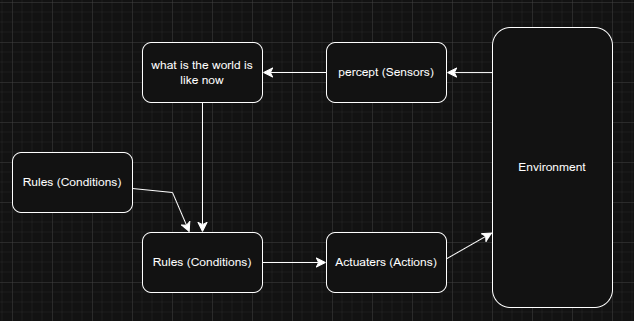

- basic sensor and rule logic
- sensor preceives the env
- there is rule based logic what to do when some conditions are met
- the acutates take the action and that intern affect the enrvironment
- example: an AC controller


### Model Based Reflex Agent

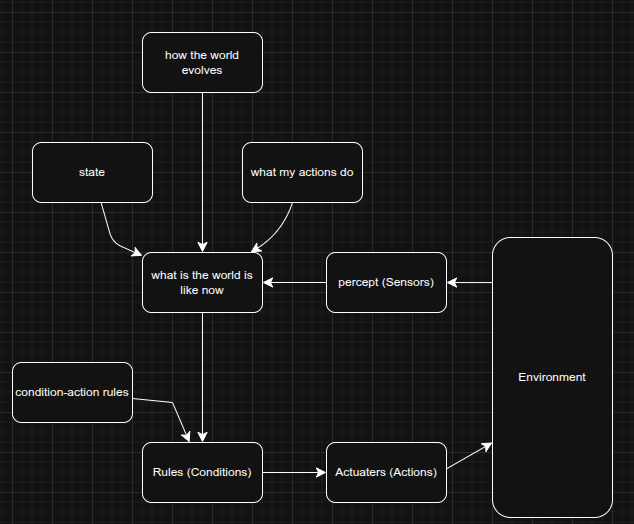

- it is a modified reflex agent
- has some idea about the world and stored in the state component
- it updated the state component
- the actions are based on the rules
- the model also tracks its actions on the enviroment (what my  actions do component)
- example: a robotic vaccum cleaner
    - where the robort earlier, what areas it has already cleaned etc in its state

### Goal based

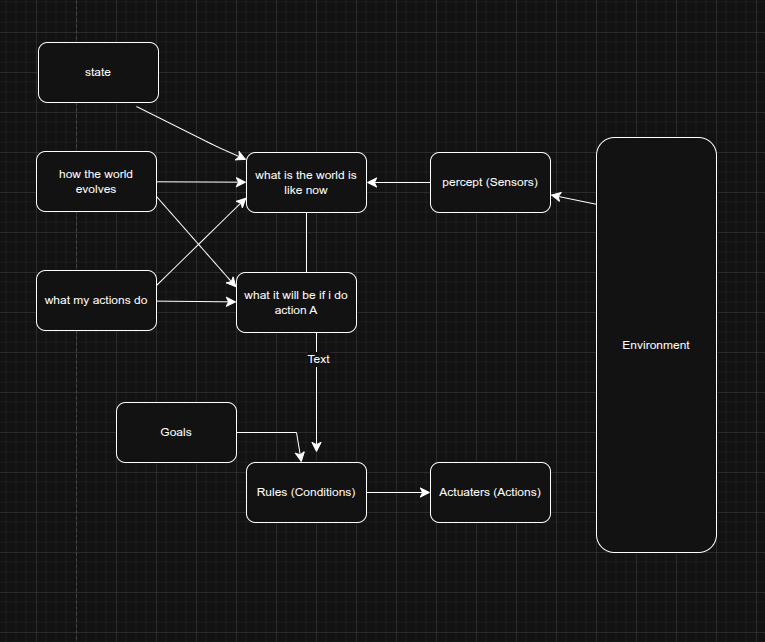
- here no condition action rules
- here we have goals (desired condition)
- example: a self driving car
    - if I turn left will i reach my destination
    - the goal is the destination point

### Utility Aased Agent

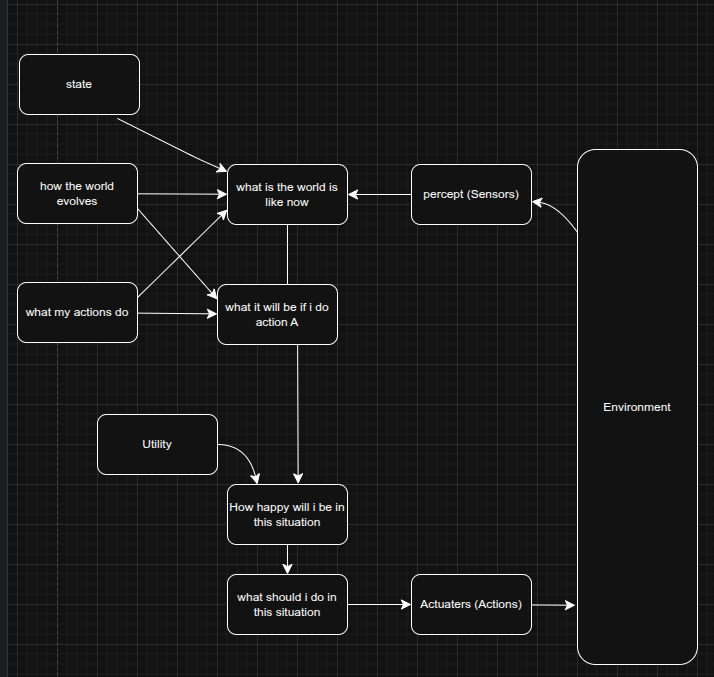
- similar to goal based agent
- however, it weights different ways to reach the goal
- and which is the most prefered way


### Learning Agent
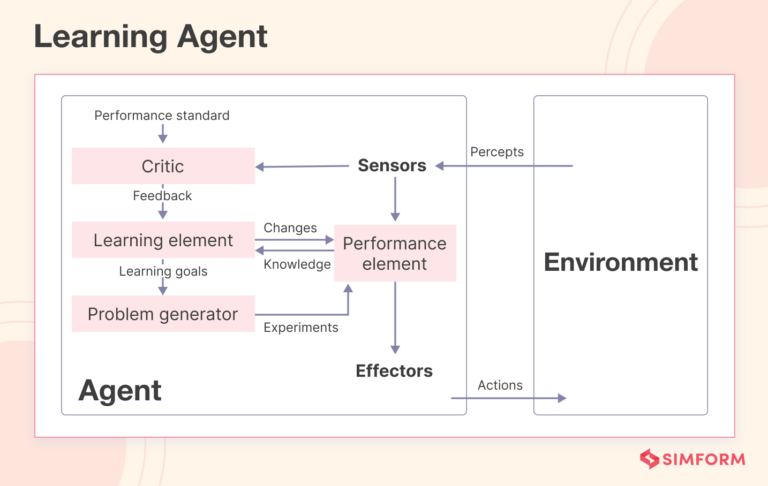

- Learns from experice
- improves  overtime from environment

- the "Critic" componet evaluate agent's action based on performance standard and generate feedback (numerical value)
- the feedback is used to update the learning element to update the agents knowledge
- the problem generator suggest new approches, that is not explored yet

### Comparison
|Reflex|Model-Based Reflex|Goal Based|Utility Based|Learning Agent|
|---|---|---|---|---|
|Reacts|Remembers|Aims|Evaluates|Improves|

## Reflextion Agents
- example in Lab

### Reflexion
- prompting technique
    - pause, review, and critique its own output

- Workflow
    - Generation node
    - Evaluation node
        - output is good enough or needs improvements
    - Refection node
        - refine the content

- Reflexive agent (Node diagram)
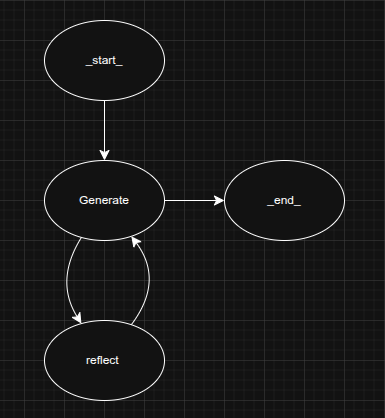

## Structuring LLM Tool Call with Pydantic and Json Serializtion
- reading available in Docs

- A schama can be attached to the LLM output

```python
# specifiy the output schema

from pydantic import BaseModel, Field

class WeatherSchema(BaseModel):
    condition: str = Field(description="Weather condition such as sunny, rainy, cloudy")
    temperature: int = Field(description="Temperature value")
    unit: str = Field(description="Temperature unit such as fahrenheit or celsius")

# attach the output schema with the model

from langchain_openai import ChatOpenAI

# Create an LLM instance
llm = ChatOpenAI(model="gpt-4.1-nano")  # or your preferred model

weather_llm = llm.bind_tools(tools=[WeatherSchema])

response = weather_llm.invoke("It's sunny and 75 degrees")

# Returns: {"condition": "sunny", "temperature": 75, "unit": "fahrenheit"}
```

### Literal
- `from typing impot Literal`
- it is a kind of regular expression that restrict the items into some particular datatypes or category

```python
from typing import Literal
def open_connection(protocol: Literal["http", "https"])
    # pass

open_connection("http") #ok
open_connection("https") #ok
# all other things will be an error
```

## Reflexion Agents
- Reflexion agents provides citations and varifiable claims
- it built around reflection agents. However it is equiped to use tools to incorporate upto date information to the generation process

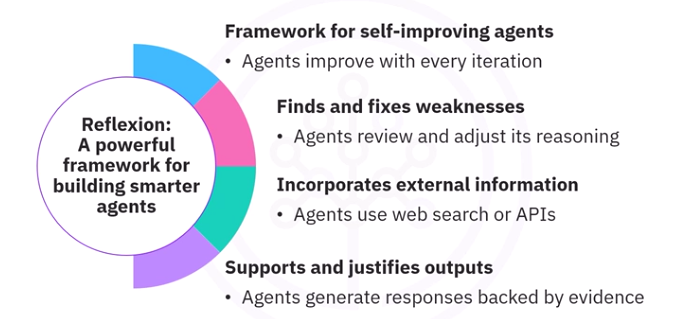



### Building Reflexion Agents

- imports
```python
import json
from typing import List, Dict
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langcahain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_community.utilites.tavily_search import TavilySearchAPIWrapper
```

- configure tools
```python
import os

os.environ["TAVILY_API_KEY"] = "xxxx"

from langchain_community.tools.trvily_search import TravilySeachResult

travily_tool = TravilySeachResults(max_result=5)
```

- search the tool
    - search result is a json dictionary
    - each with keys
        - title
        - url
        - content
```python
sample_query = "healthy brakfast recipies"
search_results = travily_tool.invoke(sample_query)
```

- create model instance and test
```python
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")

question = "Any ideas for a healthy berakfast"
llm.invoke(question).content
```

- Prompt the LLM for a respnse
```python
from langchain.prompts import ChatPromptTemplate, MessagePlaceholder
from langchain_core.messages import HumanMessage

prompt_template = ChatPromptTemplate.from_messages([
    (
        "system", 
        """
        You are Dr. Paul Saladino, "Carnivore MD," advocatomg fpr animal-based nutrition and challenging plant-centric detary dogma. Focus on the superior bioavailability of animal foods and te potential toxicity of plant conpunds like oxalates, lectins, and phytates.

        1. {first_instruction}

        2. Present the evolutionary and biochemical rationale for animal-based nutrion, emphsizing nutrient density, bioavilability, and the absenceof plant antinutiients.

        3. Challenge conventiional "plats are healthy" narriatives with mechanistic evidenc about plant defence compunds and their impact on human phsilogy.

        4. Reflect and critique your answer. Be rigorous anout evolutionary consitency and nutrient science.

        5. After the reflction, **list 1-3 search queries sperately** for researching antinutirents, bioavialibity studies, or evolutionary nutition, Donot include them inside the reflection.

        Focus on organ mets and superfoods, the carnivore elinination protocl, and why "fber is unnecessary" base on human evoutionry biology.
        """
    ), 
    MessagePlaceholder(variable_name="messages"),
    ("system", "Answer the users's question above using the required format, emphasiying animal-based nutirion superiority.")
])

# populate the fist_instruction variable

first_responder_prompt = prompt_template.partial(
    first_instruction = "Provide a detailed ~250 word answer"
)

temp_chain = first_responder_prompt | llm

response = temp_chain.invoke({
    "messages": [HumanMessage(content=question)]
})
```

- create the Reflection schema or class

```python
class Reflection(BaseModel):
    missing: str = Field(description="What information is missing")
    superfluous: str = Field(description="What information is nunecessary")

class AnswerQuestion(BaseModel):
    answer: str = Field(description = "Main response to the question")
    reflection: Reflection = Field(description="Self-critique of the answer")
    search_quries: List[str] = Field(description="Queries for additional research")
```

- chain the LLM to system message
```python
initial_chain = first_responder_prompt | llm.bind_tools(tools=[AnswerQuestion])

# invoke the new chain
response = initial_chain.invoke({"messages": HumanMessage(question)})
```

- use response_list ot test the pipeline

```python
response_list = []
response_list.append(HumanMessage(content=question))
response_list.append(response)

tool_call = response.tool_calls[0]
search_queries = tool_call["args"].get("search_queries", [])
```

- Note: the complete process is in Labs - lab-Building a Reflexion Agent

## ReAct: Integrating Resoning and Action

### ReAct: Building Agents that Reason Before Acting

- ReAct control flow
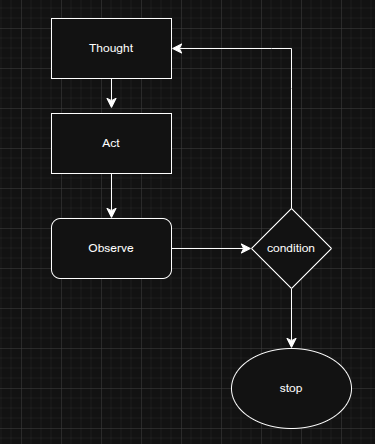

- React Agents are buit for complex task require step by step reasoning

- process flow
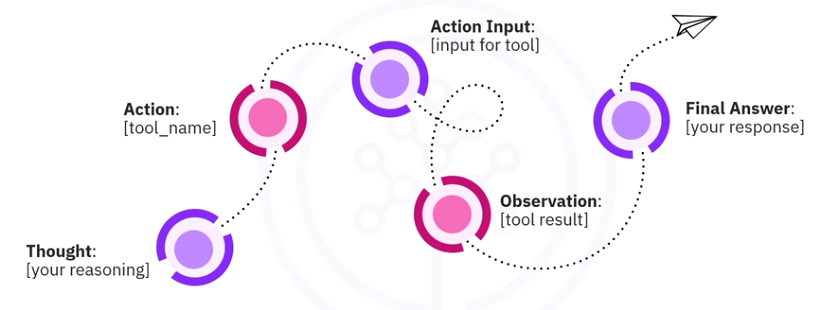


## Lab
- sample lab is available in Lab folder


### Comparison ReAct vs Reflxion Agent
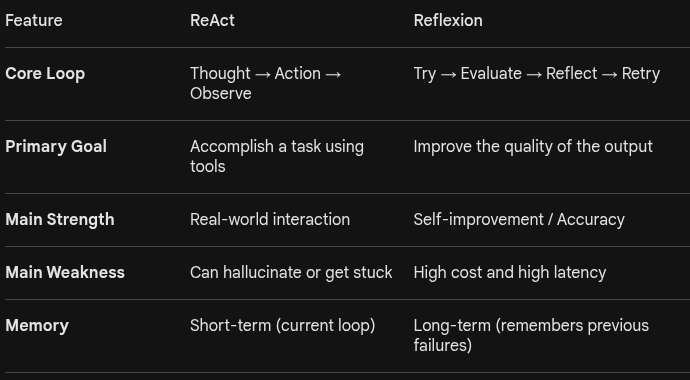